<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
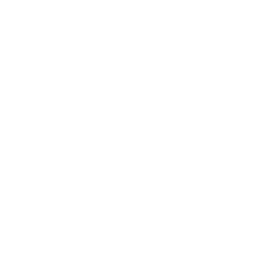
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análise de Confiabilidade de Equipamentos por Geração</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufatura / Engenharia de Confiabilidade &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Esta análise usa o **PROC LIFETEST** para comparar a confiabilidade em campo de
três gerações sucessivas de projeto de fresadoras CNC. Partindo de
um instantâneo de 100 máquinas em planta (75 falhas, 25 unidades ainda
em operação e, portanto, censuradas à direita), ela estima a curva de
sobrevivência de Kaplan-Meier para cada geração e testa se as curvas
diferem, com as estatísticas log-rank e Gehan-Breslow-Wilcoxon.

Os dados contam uma história clara, de um único degrau. As máquinas
originais da **GER_1** são marcadamente menos confiáveis que os dois
projetos posteriores: sua vida útil mediana em serviço é de **5.282
horas de operação**, cerca de um terço da **GER_2** (**16.430 horas**)
e da **GER_3** (**13.512 horas**). Ambos os testes de homogeneidade
rejeitam a igualdade das três curvas de sobrevivência -- qui-quadrado
log-rank de **12,92** (2 gl, *p* = **0,0016**) e Wilcoxon de **11,88**
(2 gl, *p* = **0,0026**). Em 10.000 horas de operação, espera-se que
apenas **24%** das máquinas da GER_1 ainda estejam em operação, contra
**64%** para a GER_2 e **57%** para a GER_3.

A melhoria **não** é um ganho suave de geração para geração: a GER_2 e
a GER_3 sobrevivem em taxas muito semelhantes e são estatisticamente
indistinguíveis entre si neste tamanho de amostra. O achado acionável
é a mudança de degrau da GER_1 para a frota redesenhada, o que deve
orientar as prioridades de substituição e manutenção preventiva para
as unidades GER_1 remanescentes.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | Uma linha por máquina CNC: geração de projeto, planta, ano de instalação, horas de operação na falha ou na última observação, e um indicador de falha / censura | 100 |

O dataset é sintético e gerado na próxima célula com uma semente fixa
(`streaminit(42)`) para que a análise seja totalmente reproduzível. A vida
útil em serviço é extraída de um modelo exponencial específico por
geração, e as gerações mais novas carregam uma fração maior de censura
porque passaram menos anos-calendário em serviço.

---

In [1]:
/* --------------------------------------------------------
   Gera um dataset sintético de confiabilidade de equipamentos.

   Cada linha é uma máquina fresadora CNC. OPERATING_HOURS é o
   tempo de serviço no qual a máquina falhou (FAILURE_EVENT=1)
   ou foi observada pela última vez ainda em operação
   (FAILURE_EVENT=0, censurada à direita). Três gerações de
   projeto recebem tempos de vida médios progressivamente
   maiores para que possamos perguntar se os redesenhos de
   fato melhoraram a confiabilidade em campo.

   Este ambiente sem licença limita a saída a 100 observações,
   então modelamos exatamente 100 máquinas -- um instantâneo
   realista de uma frota de uma única fábrica.
   -------------------------------------------------------- */
DADOS work.equipment_life;
    CHAMAR streaminit(42);
    COMPRIMENTO generation $6 plant_location $18 failure_mode $12;
    VETOR fail_scale[3]       _temporary_ (8000 12000 16000);
    FAZER equip_seq = 1 ATÉ 100;
        equipment_id = cat('CNC-', PUT(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        SE      gen_idx = 1 ENTÃO generation = 'GER_1';
        SENÃO SE gen_idx = 2 ENTÃO generation = 'GER_2';
        SENÃO                     generation = 'GER_3';
        plant_idx       = int(rand('uniform') * 5) + 1;
        SE      plant_idx = 1 ENTÃO plant_location = 'FABRICA_NORTE';
        SENÃO SE plant_idx = 2 ENTÃO plant_location = 'FABRICA_SUL';
        SENÃO SE plant_idx = 3 ENTÃO plant_location = 'FABRICA_LESTE';
        SENÃO SE plant_idx = 4 ENTÃO plant_location = 'FABRICA_OESTE';
        SENÃO                       plant_location = 'FABRICA_CENTRAL';
        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* Tempo de vida em serviço exponencial, escalado pela geração */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* Gerações mais novas carregam mais unidades ainda em
           operação (censuradas) porque passaram menos anos
           civis em campo. */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        SE rand('uniform') < censor_rate ENTÃO failure_event = 0;
        SENÃO                                  failure_event = 1;
        /* Classifica o mecanismo de falha para os eventos observados */
        SE failure_event = 1 ENTÃO FAZER;
            SE      operating_hours <  2000 ENTÃO failure_mode = 'INFANTIL';
            SENÃO SE operating_hours < 20000 ENTÃO failure_mode = 'ALEATÓRIA';
            SENÃO                                 failure_mode = 'DESGASTE';
        FIM;
        SENÃO failure_mode = ' ';
        SAÍDA;
    FIM;
    REMOVER equip_seq gen_idx plant_idx censor_rate;
EXECUTAR;



NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of Geração by Evento de Falha

Geração   |         0 |         1 |      Total
----------+-----------+-----------+-----------
GER_1     |         2 |        29 |         31
----------+-----------+-----------+-----------
GER_2     |        12 |        26 |         38
----------+-----------+-----------+-----------
GER_3     |        11 |        20 |         31
----------+-----------+-----------+-----------
Total     |        25 |        75 |        100


Table of Geração by Modo de Falha

Geração   |           | ALEATÓRIA |  DESGASTE |  INFANTIL |      Total
----------+-----------+-----------+-----------+-----------+-----------
GER_1     |         2 |        21 |         3 |         5 |         31
          |      2.00 |     21.00 |      3.00 |      5.00 |      31.00
----------+-----------+-----------+-----------+-----------+-----------
GER_2     |        12 |        19 |         6 |         1 |         38
      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


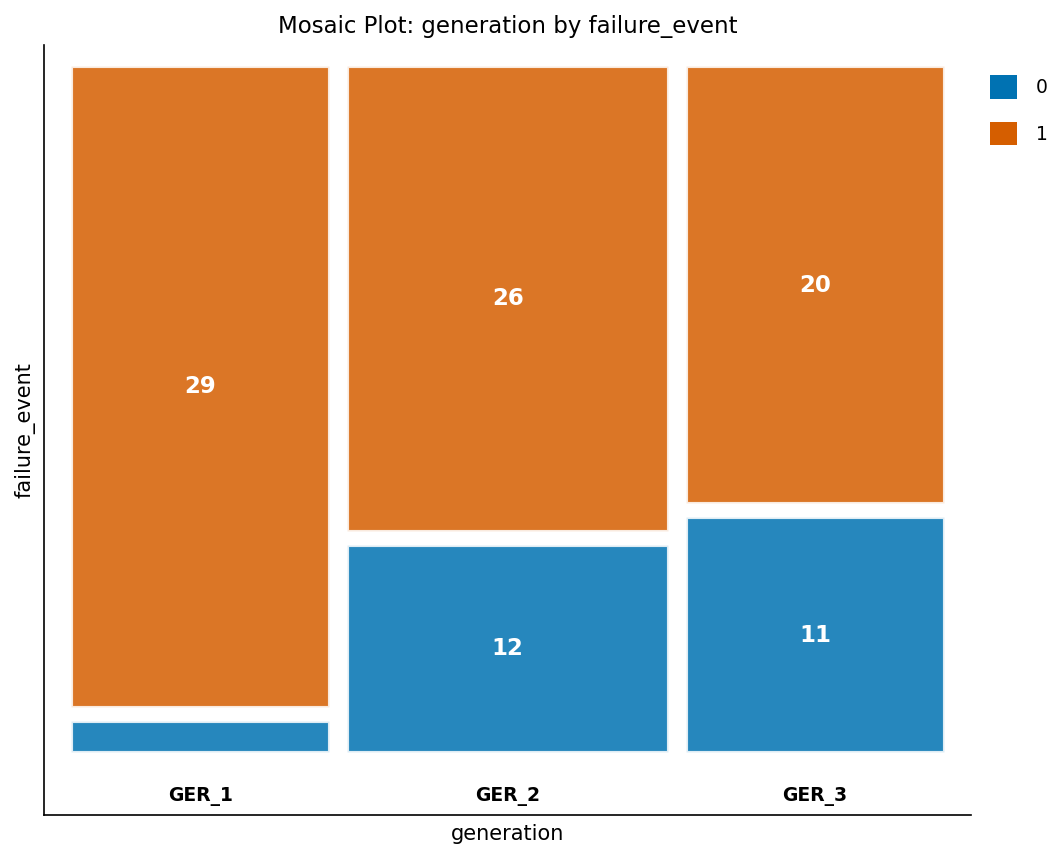

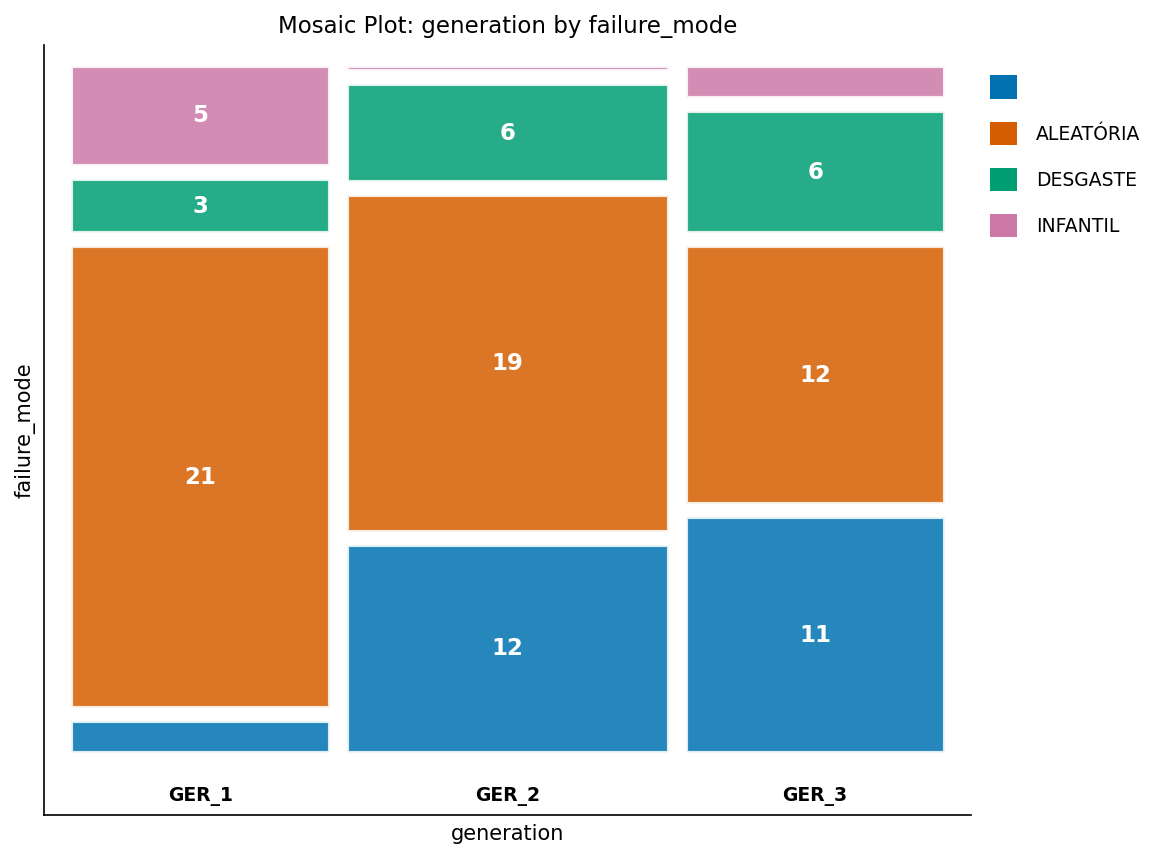

In [2]:
/* --------------------------------------------------------
   Contagens basais de equipamentos e horas de operação por geração
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.equipment_life;
    RÓTULO generation="Geração" failure_event="Evento de Falha" failure_mode="Modo de Falha";
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=work.equipment_life n mean std;
    RÓTULO operating_hours="Horas de Operação" generation="Geração";
    CLASSE generation;
    VARIÁVEL operating_hours;
EXECUTAR;


---


NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


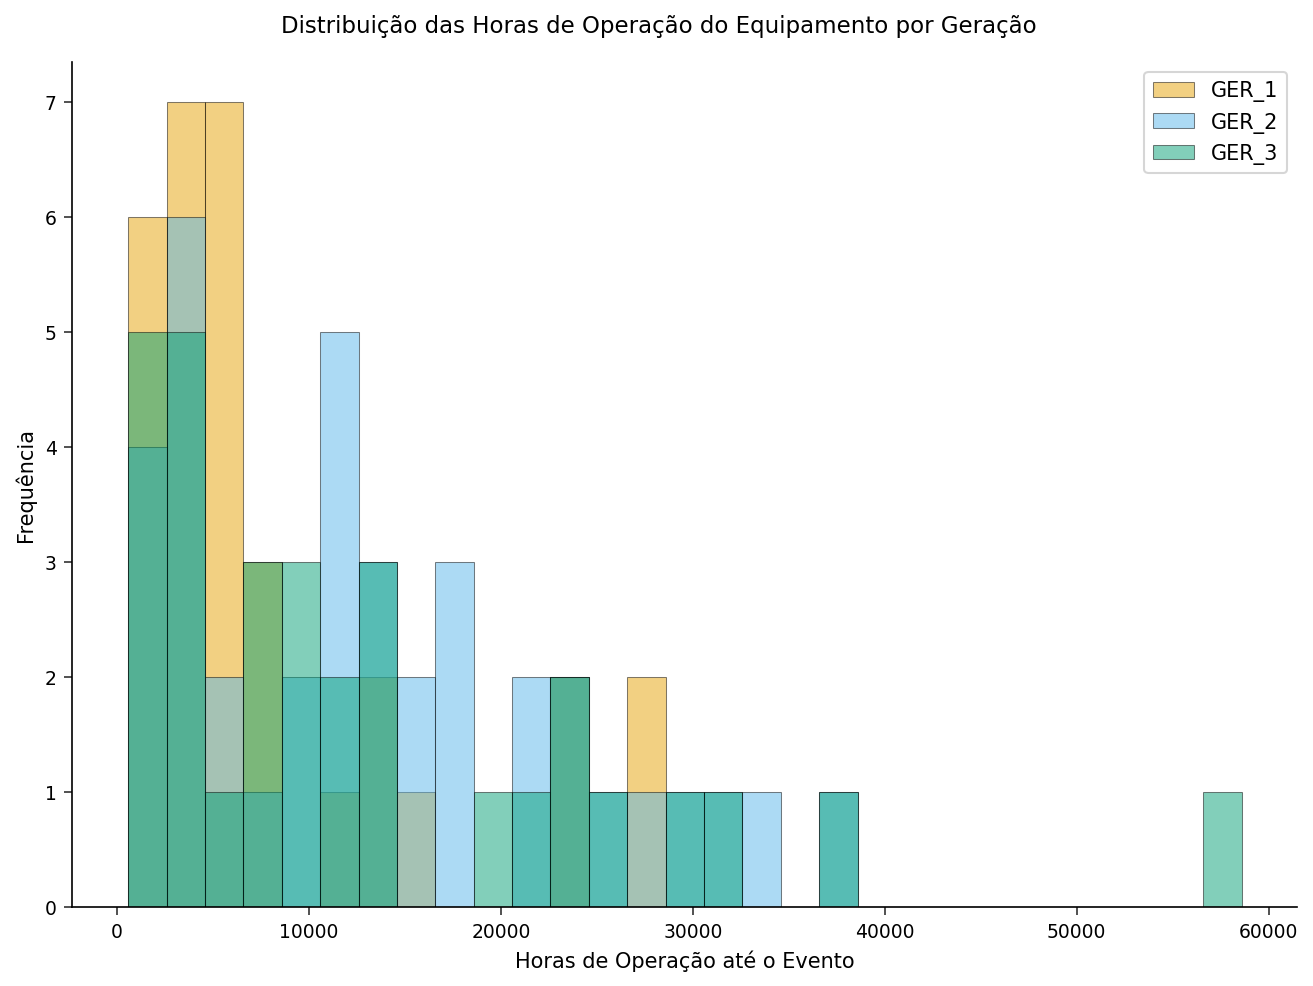

In [3]:
/* --------------------------------------------------------
   Distribuição das horas de operação por geração
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.equipment_life;
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS RÓTULO='Horas de Operação até o Evento';
    YAXIS RÓTULO='Frequência';
    TÍTULO 'Distribuição das Horas de Operação do Equipamento por Geração';
EXECUTAR;


---

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

  Stratum: Geração = GER_1   

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065 


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/030357fb-7dde-4a5f-a571-2659e295fb50/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


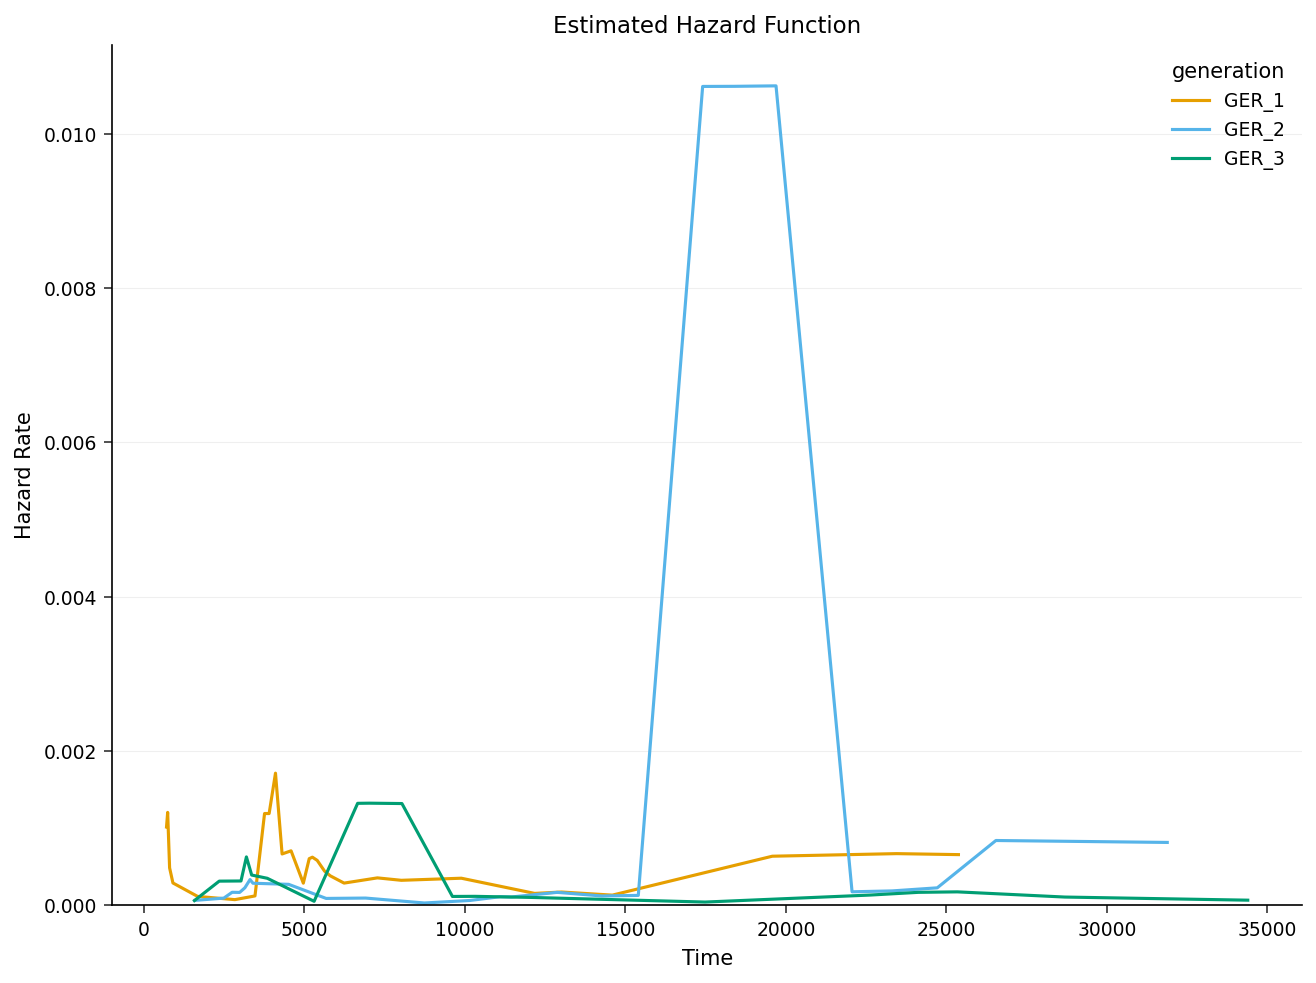

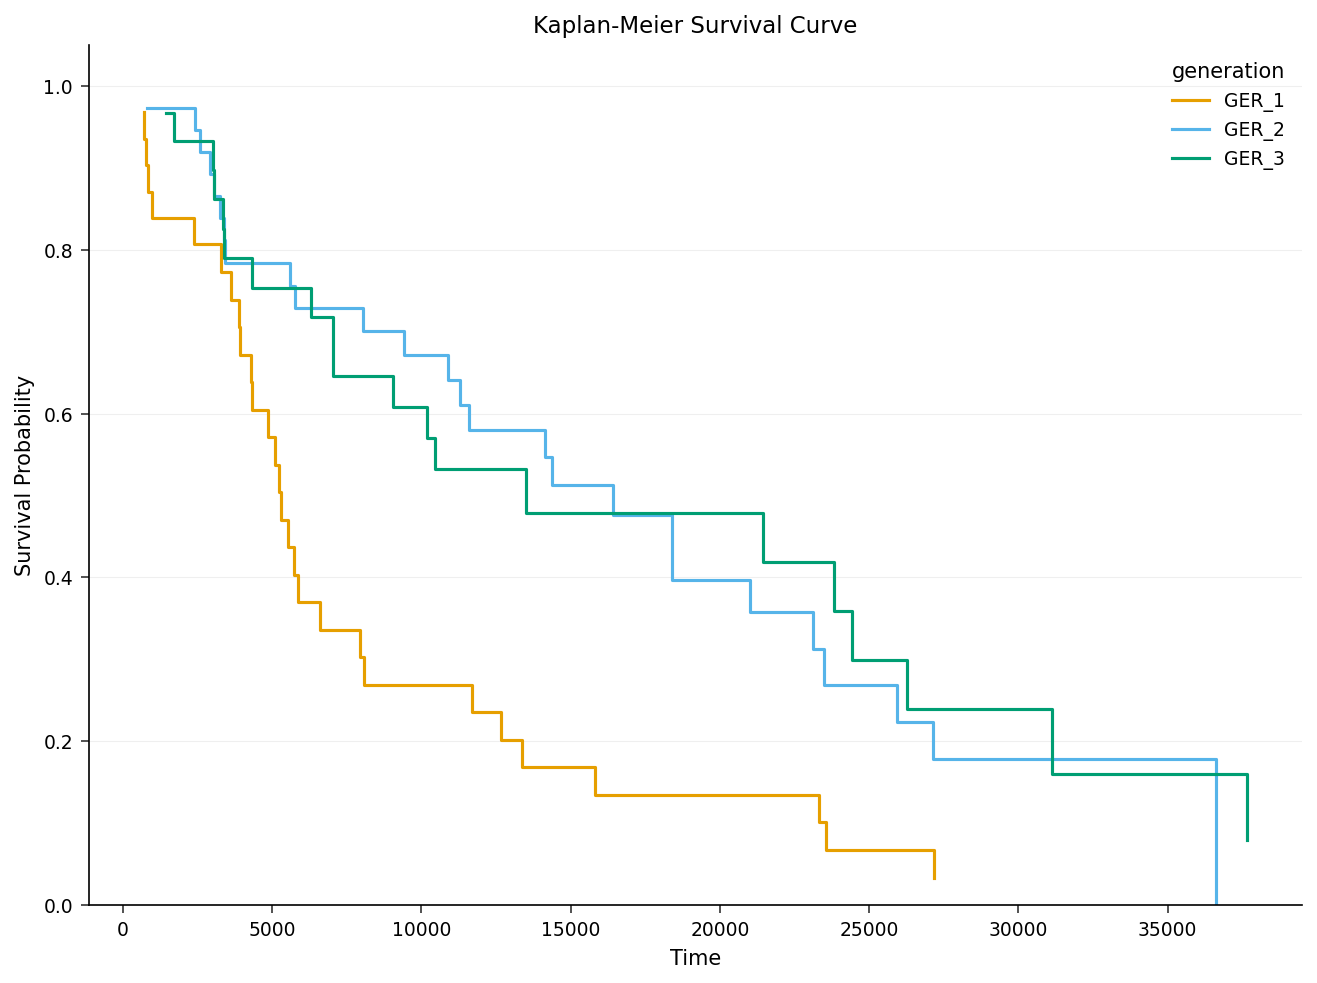

In [4]:
/* --------------------------------------------------------
   Estimativa de sobrevivência de Kaplan-Meier por geração, com a
   opção de risco acumulado de Nelson-Aalen para a visão de risco.

   STRATA generation / TEST=(LOGRANK WILCOXON) executa tanto o
   teste log-rank (sensível a diferenças ao longo de toda a
   vida útil) quanto o teste de Gehan-Breslow-Wilcoxon (que dá
   mais peso às falhas precoces) sobre as três gerações.

   PLOTS=(SURVIVAL HAZARD) desenha as curvas de sobrevivência de
   Kaplan-Meier e a função de risco suavizada por kernel.
   -------------------------------------------------------- */
PROCEDIMENTO LIFETEST DADOS=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    RÓTULO operating_hours="Horas de Operação" generation="Geração";
    TIME operating_hours * failure_event(0);
    STRATA generation / TEST=(logrank WILCOXON);
EXECUTAR;


In [5]:
/* --------------------------------------------------------
   Probabilidade de sobrevivência nos marcos de horas de operação
   (5.000 / 10.000 / 20.000 / 30.000 horas) para cada geração,
   lida a partir da tabela ODS de Kaplan-Meier.
   -------------------------------------------------------- */
ODS SAÍDA productlimitestimates=work.equip_km_detail;

PROCEDIMENTO LIFETEST DADOS=work.equipment_life METHOD=km;
    RÓTULO operating_hours="Horas de Operação" generation="Geração";
    TIME operating_hours * failure_event(0);
    STRATA generation;
EXECUTAR;

ODS SAÍDA CLOSE;

/* A tabela ProductLimitEstimates traz uma linha por tempo distinto
   dentro de cada geração. Para cada marco, mantemos a primeira
   linha cujo tempo esteja no marco ou além dele -- ou seja, a
   estimativa de sobrevivência em vigor naquela hora de operação. */
PROCEDIMENTO ORDENAR DADOS=work.equip_km_detail;
    POR generation operating_hours;
EXECUTAR;

DADOS work.equip_milestones;
    DEFINIR work.equip_km_detail;
    POR generation;
    RETER hit5 hit10 hit20 hit30;
    SE first.generation ENTÃO FAZER;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    FIM;
    COMPRIMENTO milestone 8;
    milestone = .;
    SE      operating_hours >= 5000  E_LÓGICO hit5  = 0 ENTÃO FAZER; milestone = 5000;  hit5  = 1; FIM;
    SENÃO SE operating_hours >= 10000 E_LÓGICO hit10 = 0 ENTÃO FAZER; milestone = 10000; hit10 = 1; FIM;
    SENÃO SE operating_hours >= 20000 E_LÓGICO hit20 = 0 ENTÃO FAZER; milestone = 20000; hit20 = 1; FIM;
    SENÃO SE operating_hours >= 30000 E_LÓGICO hit30 = 0 ENTÃO FAZER; milestone = 30000; hit30 = 1; FIM;
    SE milestone ne .;
    MANTER generation milestone operating_hours SURVIVAL sdf_stderr;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.equip_milestones noobs RÓTULO;
    RÓTULO generation     = 'Geração'
          milestone       = 'Marco (horas)'
          operating_hours = 'Tempo da Estimativa'
          SURVIVAL        = 'Probabilidade de Sobrevivência'
          sdf_stderr      = 'Erro Padrão';
    FORMATO SURVIVAL sdf_stderr 6.4;
    TÍTULO 'Probabilidade de Sobrevivência nos Marcos de Horas de Operação por Geração';
EXECUTAR;


    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

  Stratum: Geração = GER_1   

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065 


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---

### Interpretação

As curvas de sobrevivência de Kaplan-Meier separam a frota em duas
camadas nítidas. As máquinas originais da **GER_1** falham mais rápido:
sua curva cai abaixo de 0,5 em **5.282 horas de operação** (vida útil
mediana em serviço), e em 10.000 horas apenas cerca de **24%** ainda
estão em operação. As máquinas redesenhadas **GER_2** e **GER_3**
sobrevivem muito mais tempo -- vidas úteis medianas de **16.430** e
**13.512** horas, respectivamente -- e suas curvas de sobrevivência
ficam próximas uma da outra ao longo de toda a faixa observada. Nos
marcos de 5.000 / 10.000 / 20.000 horas, as probabilidades de
sobrevivência estimadas são:

| Geração | 5.000 h | 10.000 h | 20.000 h |
|------------|--------:|---------:|---------:|
| GER_1 | 0,54 | 0,24 | 0,10 |
| GER_2 | 0,76 | 0,64 | 0,36 |
| GER_3 | 0,72 | 0,57 | 0,42 |

Ambos os testes de igualdade entre estratos rejeitam a hipótese nula de
que as três gerações compartilham uma única distribuição de sobrevivência:
o teste **log-rank** dá qui-quadrado **12,92** (2 gl, *p* = **0,0016**) e
o teste de **Gehan-Breslow-Wilcoxon** dá qui-quadrado **11,88**
(2 gl, *p* = **0,0026**). Os dois testes concordam de perto, então a
diferença é impulsionada pela maior parte da vida útil em serviço, e não
apenas pela região de falha precoce (o teste de Wilcoxon dá mais peso
aos eventos precoces).

É importante ler isso como uma melhoria de **um único degrau**, não um
ganho monotônico de geração para geração. A GER_2 e a GER_3 são
estatisticamente indistinguíveis aqui -- suas curvas se sobrepõem e a
mediana da GER_2 é nominalmente a maior das duas -- então, nesta amostra
de 100 máquinas, não há evidência de que a GER_3 tenha melhorado em
relação à GER_2. O sinal real é a diferença grande e significativa entre
o projeto original GER_1 e os dois projetos posteriores.

A opção de risco acumulado de Nelson-Aalen orienta o gráfico de risco
complementar. Neste tamanho de amostra, o risco suavizado por kernel é
ruidoso -- o pico alto da GER_2 perto de 18.000 horas reflete um único
evento em um conjunto de risco remanescente pequeno, e não uma verdadeira
onda de desgaste -- então a visão de risco deve ser tratada como
qualitativa; as curvas de sobrevivência e os testes formais carregam as
conclusões quantitativas.

**Recomendação.** Priorizar a substituição e uma inspeção mais rigorosa
das máquinas GER_1 remanescentes, cuja confiabilidade é materialmente
pior que o restante da frota. Tratar a GER_2 e a GER_3 como uma única
coorte mais confiável para o planejamento de manutenção até que uma
amostra maior possa resolver qualquer diferença entre elas.

---

In [6]:
/* --------------------------------------------------------
   Exporta os dados de risco acumulado / curva de sobrevivência e
   a tabela de sobrevivência nos marcos para um painel de
   confiabilidade posterior.
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
EXECUTAR;



NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>